<H1>Data Science & AI Voorbeeldoverzicht</H1>

In [194]:
# Importeren van de nodige packages
# Vul zelf aan met extra packages als dit nodig is voor de oefeningen!
# Package imports for data science
import numpy as np
import pandas as pd
import scipy.stats as stats
from pandas.api.types import CategoricalDtype
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.mosaicplot import mosaic

# Package imports for time series analysis
from datetime import datetime
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.tsa.api import Holt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.linear_model import LinearRegression   # Linear regression model

from sklearn.metrics import mean_absolute_error,mean_squared_error

## Vraag 1 [2 pt]

Wat is het meetniveau van elk van deze variabelen:

1. de functie van een werknemer (uitvoerend, leidinggevend, ...)
2. het salaris van de werknemer
3. de naam van het departement van de werknemer
4. de anciënniteit (= het aantal jaren in dienst) van de werknemer




(1) ord / (2) ratio / (3) nom / (4) ratio

## Vraag 2 [3 pt]

De Vlaamse overheid wil het sociaal welbevinden van haar inwoners onderzoeken. Daarom laat ze een computer willekeurig gsm-nummers kiezen uit een databank met daarin alle bekende gsm-nummers van Vlamingen. Wanneer iemand niet reageert, wordt herhaaldelijk teruggebeld tot er een antwoord komt of tot een maximum aantal pogingen wordt bereikt.

1. Is dit een random sample? Leg uit.
2. Welk type fout(en) wordt hier gemaakt?
3. Is dit een goede sample? Leg uit.

In [195]:
# 1. nee, niet elk element heeft evenveel kans om gekozen worden
# 2. systematic sampling error
# 3. Neen (niet representatief voor de populatie, bvb senioren zonder gsm komen niet aan bod)

## Vraag 3 [6 pt]

Er zijn twee verkeerslichten op de route die een bepaald individu volgt om van zijn huis naar het werk te gaan.
E = de gebeurtenis dat het individu moet stoppen bij het eerste licht
F = de gebeurtenis dat het individu moet stoppen bij het tweede licht

$P(E)$ = 0.4
$P(F)$ = 0.3
$P(E \cap F)$ = 0.15

1. Zijn E en F onafhankelijke events? Leg kort uit waarom wel of waarom niet? wel AFHANKELIJK wnt n gelyk
2. Wat is de kans dat het individu ten minste aan één van de lichten moet stoppen? 0.55
3. Wat is de kans dat het individu aan geen van beide lichten moet stoppen?0.45
4. Wat is de kans dat het individu ten minste aan het eerste licht moet stoppen? 0.40
5. Wat is de kans dat het individu aan exact één van de lichten moet stoppen? 0.40
6. Wat is de kans dat het individu enkel aan het eerste licht moet stoppen? 0.25


In [196]:

# 1 niet onafhankelijk (afhankelijk dus) want
# P(E).P(F) <> P(E ∩ F)
# 0.4 * 0.3 <> 0.15

# 2. kans dat hij aan ten minste 1 van de beide lichten moet stoppen
# 𝑃(E ∪ F) = 𝑃(E) + 𝑃(F) − 𝑃(E ∩ F) = 0.4 + 0.3 - 0.15 = 0.55

# 3. Wat is de kans dat het individu aan geen van beide lichten moet stoppen?
# 1 - 𝑃(E ∪ F)= 0.45

# 4. Wat is de kans dat het individu ten minste aan het eerste licht moet stoppen?
# 𝑃(E) + 𝑃(E ∩ F) = 0.4                                   + 0.15 = 0.55

# 5. Wat is de kans dat het individu aan exact één van de lichten moet stoppen?
# 𝑃(𝐴 ∪ 𝐵) - P(A ∩ B) = 0.55 - 0.15

# 6. Wat is de kans dat het individu enkel aan het eerste licht moet stoppen?
0.25

0.25

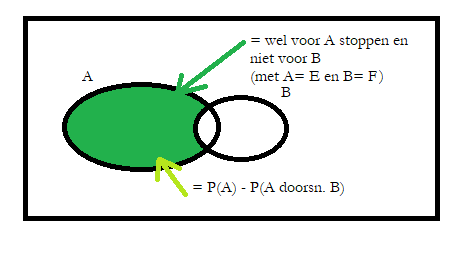

### Gegeven:
1. $ P(E) = 0.4 $  (moet stoppen bij eerste licht)
1. $ P(F) = 0.3 $  (moet stoppen bij tweede licht)
1. $ P(E \cap F) = 0.15 $  (moet bij beide stoppen)

---

## 1. Kans op exact één van de lichten moeten stoppen

Dit betekent: **wel bij het eerste of wel bij het tweede, maar niet bij beide**.

Formule:
$$
P(\text{exact één}) = P(E \setminus F) + P(F \setminus E)
$$
$$
= P(E) - P(E \cap F) + P(F) - P(E \cap F)
$$
$$
= [0.4 - 0.15] + [0.3 - 0.15] = 0.25 + 0.15 = 0.40
$$

**Antwoord:**  
De kans dat het individu bij exact één van de lichten moet stoppen is **0,40**.

---

## 2. Kans op enkel aan het eerste licht moeten stoppen

Dit betekent: **wel bij het eerste, niet bij het tweede**.

Formule:
$$
P(E \setminus F) = P(E) - P(E \cap F) = 0.4 - 0.15 = 0.25
$$

**Antwoord:**  
De kans dat het individu enkel aan het eerste licht moet stoppen is **0,25**.

---

#### Samenvatting in tabel

| Gebeurtenis                           | Kans  |
|----------------------------------------|-------|
| Exact één van beide lichten            | 0,40  |
| Enkel aan het eerste licht             | 0,25  |

**Gebruikte formules:**  
1. $$ P(A \setminus B) = P(A) - P(A \cap B) $$
1. $$ P(\text{exact één}) = P(E \setminus F) + P(F \setminus E) $$

## Vraag 4 [4 pt]

Stel dat de verdeling van de netto-typsnelheid in
woorden per minuut (wpm) voor ervaren typisten kan worden
benaderd kan worden door een normale curve met gemiddelde 65 wpm en
standaardafwijking 15 wpm
1. Wat is de kans dat de netto-snelheid van een willekeurig gekozen typist
maximaal 60 wpm is?
2. Wat is de kans dat de netto-snelheid van een willekeurig gekozen typist
nettosnelheid tussen 45 en 90 wpm ligt?
3. Zou je verbaasd zijn om een typist te vinden
wiens netto-snelheid hoger is dan 105 wpm?
4. Stel dat een speciale training zal worden gegeven aan de langzaamste 20% van de typisten. Welke typesnelheden zouden in aanmerking komen voor deze opleiding?

In [197]:
mu = 65
sigma = 15

# 1. Wat is de kans dat de netto-snelheid van een willekeurig gekozen typist maximaal 60 wpm is?
VA1= stats.norm.cdf(60, loc=mu, scale=sigma)
# 2. Wat is de kans dat de netto-snelheid van een willekeurig gekozen typist nettosnelheid tussen 45 en 90 wpm ligt?
VA2= stats.norm.cdf(90, loc=mu, scale=sigma) - stats.norm.cdf(45, loc=mu, scale=sigma)
# 3. Wat is de kans om een typist te vinden wiens netto-snelheid hoger is dan 105 wpm?
VA3= stats.norm.sf(105, loc=mu, scale=sigma)
# 4. Stel dat een speciale training zal worden gegeven aan de langzaamste 20% van de typisten.
# Welke typesnelheden zouden in aanmerking komen voor deze opleiding?
VA4= stats.norm.isf(1-0.2, loc=mu, scale=sigma)
print("eers", round(VA1, 4), round(VA2, 4), round(VA3, 4), round(VA4, 4))

mu = 60
sigma = 15

# 1. Wat is de kans dat de netto-snelheid van een willekeurig gekozen typist maximaal 65 wpm is?
VB1= stats.norm.cdf(65, loc=mu, scale=sigma)
# 2. Wat is de kans dat de netto-snelheid van een willekeurig gekozen typist nettosnelheid tussen 45 en 90 wpm ligt?
VB2= stats.norm.cdf(90, loc=mu, scale=sigma) - stats.norm.cdf(45, loc=mu, scale=sigma)
# 3. Wat is de kans om een typist te vinden wiens netto-snelheid hoger is dan 105 wpm?
VB3= stats.norm.sf(105, loc=mu, scale=sigma)
# 4. Stel dat een speciale training zal worden gegeven aan de langzaamste 20% van de typisten. Welke typesnelheden zouden in aanmerking komen voor deze opleiding?
VB4= stats.norm.isf(1-0.2, loc=mu, scale=sigma)
print("*** zerty *** ===>> ", round(VB1, 4), round(VB2, 4), round(VB3, 4), round(VB4, 4))



eers 0.3694 0.861 0.0038 52.3757
*** zerty *** ===>>  0.6306 0.8186 0.0013 47.3757


In [198]:
mu = 60
sigma = 15

# 1. Wat is de kans dat de netto-snelheid van een willekeurig gekozen typist maximaal 60 wpm is?
VA1= stats.norm.cdf(60, loc=mu, scale=sigma)
# 2. Wat is de kans dat de netto-snelheid van een willekeurig gekozen typist nettosnelheid tussen 45 en 90 wpm ligt?
VA2= stats.norm.cdf(90, loc=mu, scale=sigma) - stats.norm.cdf(45, loc=mu, scale=sigma)
# 3. Wat is de kans om een typist te vinden wiens netto-snelheid hoger is dan 105 wpm?
VA3= stats.norm.sf(105, loc=mu, scale=sigma)
# 4. Stel dat een speciale training zal worden gegeven aan de langzaamste 20% van de typisten. Welke typesnelheden zouden in aanmerking komen voor deze opleiding?
VA4= stats.norm.isf(1-0.2, loc=mu, scale=sigma)
print("dred", round(VA1, 4), round(VA2, 4), round(VA3, 4), round(VA4, 4))


dred 0.5 0.8186 0.0013 47.3757


## Vraag 5 [2 pt]

We weten op basis van historische data dat de vluchttijden (in minuten) voor een specifieke vlucht normaal verdeeld zijn.
De gemeten vluchttijden tussen 1 januari en 31 maart zijn hieronder gegeven.


1. Bereken en geef een 90% betrouwbaarheidsinterval voor
de gemiddelde vluchttijd voor deze vlucht.   [ 53,2815 ; 55,1185 ]


In [199]:
vluchttijden = np.array([57, 54, 55, 51, 56, 48, 52, 51, 59, 59, 57, 54, 55, 51, 56, 48, 52, 51, 59, 59, 57, 54, 55, 51, 56, 48, 52, 51, 59, 59, 57, 54, 55, 51, 56, 48, 52, 51, 59, 59])

In [200]:
# 1. Bereken en geef een 90% betrouwbaarheidsinterval voor de gemiddelde vlluchttijd voor deze vlucht.
# Step 1.
m = np.mean(vluchttijden)      # Sample mean
s = np.std(vluchttijden, ddof = 1)      # Sample (!) standard deviation
n = len(vluchttijden)       # Sample size
alpha = .1  # 1 - alpha is the confidence level

# Stap 2.
z = stats.norm.isf(alpha/2)
print("t-score: %.5f" % z)


# Stap 3.
lo = m - z * s / np.sqrt(n)
hi = m + z * s / np.sqrt(n)
print("Confidence interval: [%.4f, %.4f]" % (lo, hi))


t-score: 1.64485
Confidence interval: [53.2815, 55.1185]


# Vraag 6 [5 pt]
In een studie werden patiënten met een hoge bloeddruk willekeurig toegewezen aan één van twee groepen. In de 'praatgroep' werden vragen gesteld over hun medische geschiedenis en over de strefssfactoren in hun leven in de minuten voorafgaand aan het meten van de bloeddruk. In de 'telgroep' werd gevraagd vier keer hardop te tellen van 1 tot 100 voordat de bloeddruk werd gemeten.
Is er een verschil in bloeddruk tussen de twee groepen?


1. Maak een plot
2. Welke hypothesetoets ga je toepassen om deze onderzoeksvraag te beantwoorden? Wees zo specifiek mogelijk! LET T² unpaired (indpt)
3. Formuleer de nulhypothese en de alternatieve hypothese   ***   ===>>   H1: mu1 - mu2 != 0   ***
4. Bereken de p-waarde   ===>>   0,0227
5. Trek een besluit op basis van de vorige stap en formuleer een antwoord op de onderzoeksvraag.   === <<   H0 verwerpen   ***   (want p < significantieniveau v/5 %)


In [201]:
praatgroep = [104, 110, 107, 112, 108, 103, 108, 118]
telgroep = [110, 96, 103, 98, 100, 109, 97, 105]

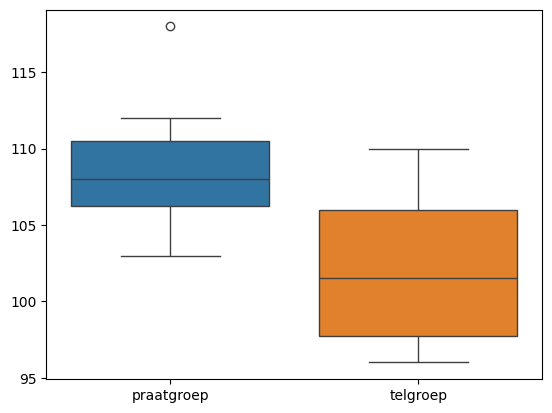

In [202]:
# 1. Plot van de casus
bloeddruk = pd.DataFrame(data={
  'praatgroep': praatgroep,
  'telgroep': telgroep
})
sns.boxplot(data=bloeddruk);

In [203]:
print(np.mean(praatgroep) - np.mean(telgroep))

6.5


In [204]:
s, pvalue = stats.ttest_ind(a=praatgroep, b=telgroep,
    alternative='two-sided', equal_var=True)
print(round(s, 4), round(pvalue, 4))

2.5601 0.0227


In [205]:
# 2. Welke hypothesetoets ga je toepassen om deze onderzoeksvraag te beantwoorden? Wees zo specifiek mogelijk!
# Two-sample t-test voor Independent samples

# 3. Formuleer de nulhypothese en de alternatieve hypothese
# H0 = Er is geen verschil in bloeddruk tussen de beide groepen
# H1 = Er is een verschil in bloeddruk tussen de beide groepen

# 4. Bereken de p-waarde
# p-value = 0.0226

# 5. Trek een besluit op basis van de vorige stap en formuleer een antwoord op de onderzoeksvraag.
# Er is voldoende reden om H0 te verwerpen
# Er is een significant verschil in bloeddruk tussen de 2 groepen.

## Vraag 7 [8 pt]

Het aantal werknemers op de loonlijst bij een voedingsverwerkend bedrijf wordt aan het begin van elke maand geregistreerd.
Deze gegevens staan hieronder.

1. Geef de datatypes van beide kolommen     ===>>   *****   int & object   *****
2. Vorm de kolom 'datum' om naar het type datetime. Ook als dit je niet lukt kan je verder werken.
3. Maak de volgende plot.

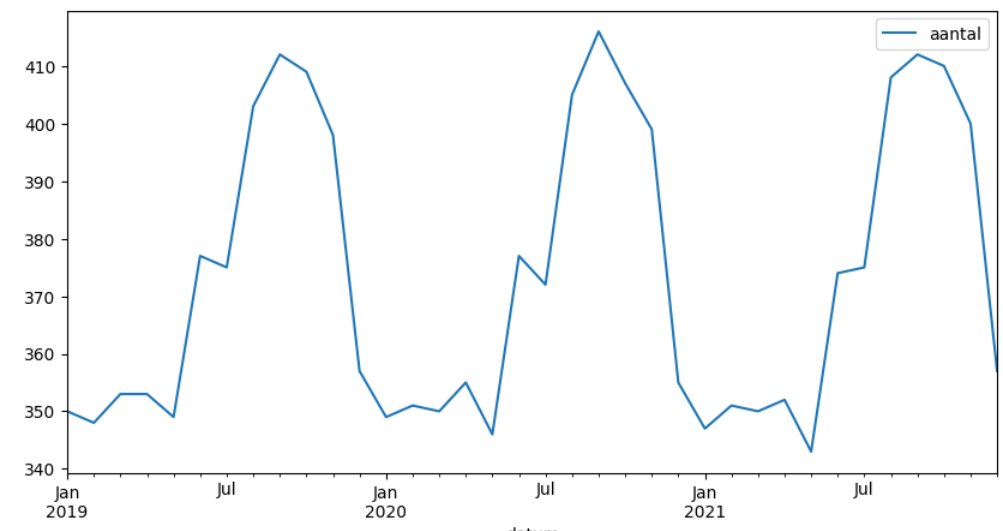

4. Maak een voorspelling voor de eerste vier maanden van het volgende jaar met behulp van de meest geschikte methode. Leg uit waarom je voor deze methode kiest.
5. Maak een plot inclusief de prognose.
6. Maak de volgende berekeningen
- 6.1 Bereken het gemiddeld aantal werknemers in 2020   ===>>>>>>>   373,5
- 6.2 Hoeveel maanden telde het bedrijf meer dan 400 werknemers?   ===>>>>>>>   9




In [206]:
# 1. Geef de datatypes van beide kolommen
# # # dfwerknemers.dtypes
print("Zie verder!")

Zie verder!


In [207]:
dfwerknemers = pd.DataFrame(data={
    'datum': ['2019/01/01', '2019/02/01', '2019/03/01', '2019/04/01', '2019/05/01', '2019/06/01', '2019/07/01', '2019/08/01', '2019/09/01', '2019/10/01', '2019/11/01', '2019/12/01', '2020/01/01', '2020/02/01', '2020/03/01', '2020/04/01', '2020/05/01', '2020/06/01', '2020/07/01', '2020/08/01', '2020/09/01', '2020/10/01', '2020/11/01', '2020/12/01', '2021/01/01', '2021/02/01', '2021/03/01', '2021/04/01', '2021/05/01', '2021/06/01', '2021/07/01', '2021/08/01', '2021/09/01', '2021/10/01', '2021/11/01', '2021/12/01'],
    'aantal': [350,348,353,353,349,377,375,403,412,409,398,357,349,351,350,355,346,377,372,405,416,407,399,355,347,351,350,352,343,374,375,408,412,410,400,357]
})


In [208]:
# 1. Geef de datatypes van beide kolommen
dfwerknemers.dtypes

datum     object
aantal     int64
dtype: object

In [209]:
# 2. Vorm de kolom 'datum' om naar het type datetime. Ook als dit je niet lukt kan je verder werken.
dfwerknemers['datum'] = pd.to_datetime(dfwerknemers['datum'], format = '%Y/%m/%d')

In [210]:
dfwerknemers = dfwerknemers.set_index(['datum'])
dfwerknemers.head()

,aantal
datum,
2019-01-01,350
2019-02-01,348
2019-03-01,353
2019-04-01,353
2019-05-01,349


<Axes: xlabel='datum'>

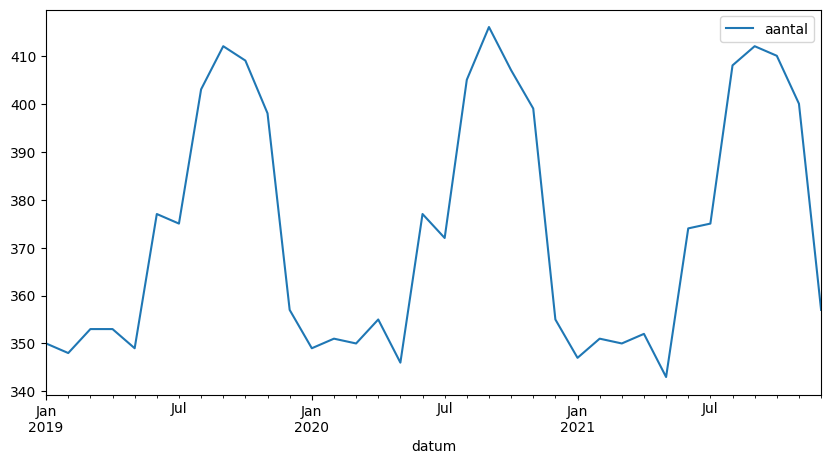

In [211]:
# 3. Maak de volgende plot.
dfwerknemers.plot( y='aantal', figsize= [10, 5])

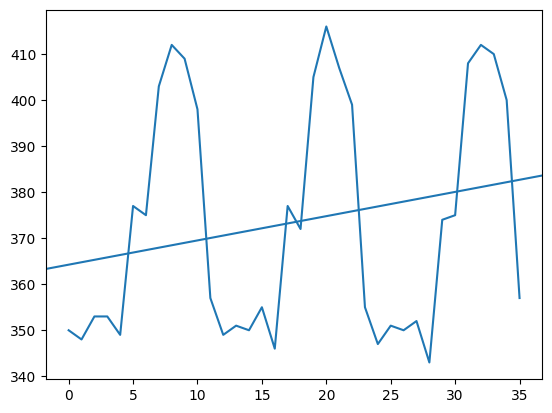

In [ ]:
# iser een trend
werknemers_lm = LinearRegression().fit(
    np.arange(0,36).reshape((-1,1)),
    dfwerknemers.aantal.values
)

# plot the time series and the regression line
plt.plot(np.arange(0,36), dfwerknemers.aantal);
plt.axline((0, werknemers_lm.intercept_), slope=werknemers_lm.coef_[0]);

In [213]:
# 4 Maak een voorspelling voor de eerste vier maanden van het volgende jaar met behulp van de meest geschikte methode.
# Leg uit waarom je voor deze methode kiest.
# Holt Winters omdat er een trend + seasonal component is

from statsmodels.tsa.holtwinters import ExponentialSmoothing

model = ExponentialSmoothing(dfwerknemers['aantal'],
  trend='add', seasonal='add',
  seasonal_periods=12, freq='MS').fit()

dfwerknemers['TES'] = model.fittedvalues
dfwerknemers.head()

,aantal,TES
datum,,
2019-01-01,350,348.874862
2019-02-01,348,350.208235
2019-03-01,353,351.208200
2019-04-01,353,353.541569
2019-05-01,349,346.208216


In [214]:
predicted = model.forecast(12)

Text(0.5, 1.0, 'Aantal werknemers Voedingsverwerkend bedrijf')

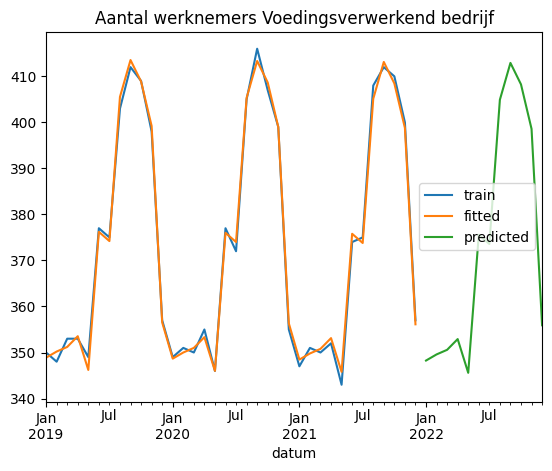

In [215]:
# 5. Maak een plot inclusief de prognose.

dfwerknemers['aantal'].plot(legend=True, label='train')
dfwerknemers['TES'].plot(legend=True, label='fitted')

predicted.plot(legend=True, label='predicted')

plt.title('Aantal werknemers Voedingsverwerkend bedrijf')

In [216]:
# 6.1. Bereken het gemiddeld aantal werknemers in 2020
ant6_1= dfwerknemers['2020/01/01':'2020/12/01']['aantal'].mean()
print("ant6_1=", ant6_1)


# 6.2. Hoeveel maanden telde het bedrijf meer dan 400 werknemers?
print(dfwerknemers[dfwerknemers.aantal > 400]['aantal'].count())

ant6_1= 373.5
9


## Vraag 8 [5 pt]
Een toenemende zorg van werkgevers is de tijd die werknemers besteden aan 'surfen op het net voor niet professionele doeleinden'. Men schat dat per werknemer 2 uur per dag hieraan verloren gaat. Stel dat de CEO van een groot bedrijf wil bepalen of de gemiddelde hoeveelheid verspilde tijd minder is dan de gerapporteerde 120 minuten. In een willekeurige steekproef worden 10 werknemers gecontacteerd en wordt gevraagd naar de dagelijks verspilde tijd op het werk. (Er wordt waarschijnlijk anonimiteit gegarandeerd om waarheidsgetrouwe antwoorden te krijgen).
Bewijzen de onderstaande gegevens dat de gemiddelde verspilde tijd voor dit bedrijf minder dan 120 minuten is?
Voer een test uit met 5% significance level om deze vraag te beantwoorden.

1. Welke hypothesetoets ga je toepassen om deze onderzoeksvraag te beantwoorden? Wees zo specifiek mogelijk! T of z; 'speelt g rol; zie mod.ant ('wèér (t)) / LET
2. Formuleer de nulhypothese en de alternatieve hypothese c-l
3. Bereken de gepaste toetsingsgrootheid (teststatistiek) voor deze toets. Geef het symbool en de waarde xbar= 116,8 u (òf 125,5 (ca. (t)))   -1.07091     125,478 (t)
4. Bereken de p-waarde 0,8440      <<=====>> 0.156
5. Trek een besluit op basis van de vorige stap en formuleer een antwoord op de onderzoeksvraag. H0 behouden; n minder

In [217]:
verspilde_tijd = [108, 112, 117, 130, 111, 131, 113, 113, 105, 128]

The testing procedure then runs as follows:

**Step 1.** Formulate the hypotheses:

- $H_0: \mu = 120$
- $H_1: \mu < 120$

**Step 2.** Choose a significance level, e.g. $\alpha = 0.05$

In [218]:
# Properties of the sample:
n = len(verspilde_tijd)      # sample size
sm =  np.mean(verspilde_tijd)  # sample mean
s = np.std(verspilde_tijd, ddof = 1)
a = 0.05    # significance level (chosen by the researcher)
m0 = 120   # hypothetical population mean (H0)
print(n, sm, s, a, m0)

10 116.8 9.44927980794774 0.05 120


A plot of this case:

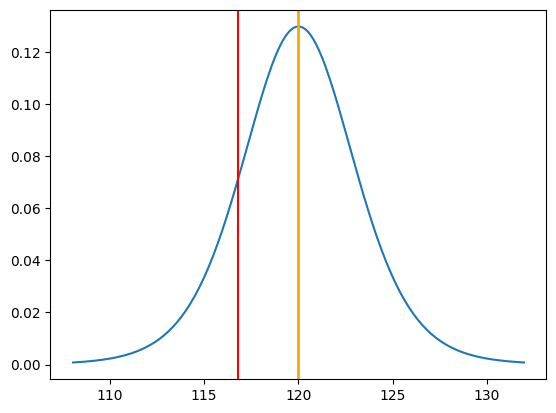

In [219]:
# Gauss-curve plot:
# X-values
dist_x = np.linspace(m0 - 4 * s/np.sqrt(n), m0 + 4 * s/np.sqrt(n), num=201)
# Y-values for the Gauss curve
dist_y = stats.t.pdf(dist_x, loc = m0, scale = s/np.sqrt(n), df = n - 1)
fig, dplot = plt.subplots(1, 1)
# Plot the Gauss-curve
dplot.plot(dist_x, dist_y)
# Show the hypothetical population mean with an orange line
dplot.axvline(m0, color="orange", lw=2)
# Show the sample mean with a red line
dplot.axvline(sm, color="red")

**Step 3.** Determine the value of the test statistic, in this case $\overline{x} = 116.800$

**Step 4.**

<u>Method 1</u>

Determine the $p$-value and reject $H_0$ if $p < \alpha$.
The $p$-value is the probability, if the null hypothesis is true, to obtain
a value for the test statistic that is at least as extreme as the
observed value


In [220]:
p = stats.t.sf(sm, loc=m0, scale=s/np.sqrt(n), df = n -1)
print("p-value: %.5f" % p)
if(p < a):
    print("p < a: reject H0")
else:
    print("p > a: do not reject H0")

p-value: 0.84396
p > a: do not reject H0


<u>Method 2</u>

An alternative method is to determine the critical region, i.e. the set of all values for the sample mean where $H_0$ may be rejected.
The boundary of that area is called the critical value $g$. To the left of it you can't reject $H_0$ (acceptance region), to the right you can (critical region). The area of the acceptance region is $1 - \alpha$, the area of the critical region is $\alpha$.

In [221]:
g = stats.t.isf(a, loc = m0, scale = s / np.sqrt(n), df = n - 1)
print("Critical value g ≃ %.3f" % g)
if (sm < g):
    print("sample mean = %.3f < g = %.3f: do not reject H0" % (sm, g))
else:
    print("sample mean = %.3f > g = %.3f: reject H0" % (sm, g))

Critical value g ≃ 125.478
sample mean = 116.800 < g = 125.478: do not reject H0


**Step 5**
We can conclude that there is not enough evidence to reject the null hypothesis.

## Vraag 9 [6 pt]

Een maatstaf voor het succes van een knieoperatie is het bewegingsbereik van het kniegewricht na de operatie. Het postoperatieve bewegingsbereik werd geregistreerd voor 12 patiënten na een knieoperatie. De leeftijd van elke patiënt werd ook geregistreerd. De gegevens zijn hieronder gegeven.

1. Maak de onderstaande grafiek
2. Geef de vergelijking van de regressierechte   ===>> y= 107.58 + x.0,87
3. Geef het geschatte bewegingsbereik van iemand van 38 jaar oud.   ===>> 140,68
4. Bereken de correlatiecoëfficient (symbool + waarde)   ===>> r= 0,5534
5. Geef de interpretatie voor de waarde van de correlatiecoëfficient
6. Stel dat we het bewegingsbereik uitdrukken als een hoek in radialen in plaats van een hoek in graden, zal de waarde van de correlatiecoëfficient dan veranderen? Illustreer je antwoord met de opgegeven data.
hoek in radialen = hoek in graden / 180 * $π$


In [222]:
dfknie = pd.DataFrame(data={'leeftijd': [35, 24, 40, 31, 28, 25, 26, 16, 14, 20, 21, 30],
                            'bewegingsbereik': [154, 142, 137, 133, 122, 126, 135, 135, 108, 120, 127, 122]})

<Axes: xlabel='leeftijd', ylabel='bewegingsbereik'>

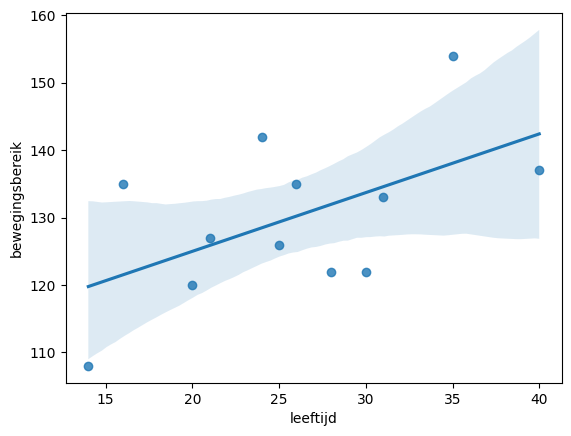

In [223]:
# (1) Maak de onderstaande grafiek
sns.regplot(x=dfknie.leeftijd, y=dfknie.bewegingsbereik)

In [224]:
# (2) Geef de vergelijking van de regressierechte
from sklearn.linear_model import LinearRegression

x = dfknie.leeftijd.values.reshape(-1,1)
y = dfknie.bewegingsbereik

model = LinearRegression().fit(x, y)

print(f"Regression line: ŷ = {model.intercept_} + {model.coef_[0]} x")

Regression line: ŷ = 107.58311345646439 + 0.8709762532981529 x


In [225]:
# (3) Calculate the determination coefficient (symbol + value)
cor = np.corrcoef(dfknie.leeftijd, dfknie.bewegingsbereik)[0][1]
print('r=', round(cor, 4))
print(f"R² = {round(cor ** 2, 4)}")

r= 0.5534
R² = 0.3062


In [226]:
# (4) Formulate an interpretation
# R² ~ 0.3: matig verband + 30% van de variantie van de afhankelijk veranderlijke wordt verklaard door de afhankelijk veranderlijke
# Als de eenheden veranderen, zal de waarde van R² niet veranderen

In [227]:
# (5) Stel dat we het bewegingsbereik uitdrukken als een hoek in radialen in plaats van een hoek in graden, zal de waarde van de determinatiecoëfficiënt dan veranderen?
# Illustreer je antwoord met de opgegeven data.
# hoek in radialen = hoek in graden / 180 *  π

dfknie['radialen'] = dfknie['bewegingsbereik'] / 180 * 3.14
cor = np.corrcoef(dfknie.leeftijd, dfknie.radialen)[0][1]
print(f"R² = {round(cor ** 2, 4)}")

R² = 0.3062


In [228]:
cor = np.corrcoef(dfknie.leeftijd, dfknie.radialen)[0][1]
print(f"R² = {round(cor ** 2, 4)}")

R² = 0.3062


In [229]:
# (6) Geef het geschatte bewegingsbereik van iemand van 38 jaar oud.
print(round(model.predict([[38]])[0], 4))

140.6802


In [230]:
dfknie['voorspelling'] = dfknie['leeftijd'].map(lambda x: model.predict([[x]])[0])
dfknie.head()

,leeftijd,bewegingsbereik,radialen,voorspelling
0,35,154,2.686444,138.067282
1,24,142,2.477111,128.486544
2,40,137,2.389889,142.422164
3,31,133,2.320111,134.583377
4,28,122,2.128222,131.970449


In [231]:
# 7. Bereken het gemiddelde van de squared residuals van de gegeven waarden.
from sklearn.metrics import mean_absolute_error,mean_squared_error
print(f"MSE = {round(mean_squared_error(dfknie['bewegingsbereik'], dfknie['voorspelling']), 4)}")

MSE = 90.4779


In [232]:
# alternatieve werkwijze
dfknie['verschil'] = (dfknie['voorspelling'] - dfknie['bewegingsbereik']) ** 2
print(round(dfknie['verschil'].mean(), 4))

90.4779


## Vraag 10 [6 pt]
Een volkswijsheid luidt dat er meer kinderen geboren worden gedurende bepaalde fasen van de maancyclus, in het bijzonder bij volle maan. In 2005 werd een classificatie gedaan van het aantal geboortes alnaargelang de maancyclus.
Een steekproef van het aantal geboortes gedurende verschillende maancycli wordt hieronder gegeven.
Is er een verband tussen de maancyclus en het aantal geboortes?

1. Welke hypothesetoets ga je toepassen om deze onderzoeksvraag te beantwoorden? Wees zo specifiek mogelijk! goodness of fit
2. Formuleer de nulhypothese en de alternatieve hypothese er is (wel) verb
3. Bereken de gepaste toetsingsgrootheid (teststatistiek) voor deze toets. Geef het symbool en de waarde chi2 = 6.3111
4. Bereken de p-waarde p = 0.5039
5. Trek een besluit op basis van de vorige stap en formuleer een antwoord op de onderzoeksvraag. H0 behouden: Er is geen verband tussen de maancyclus en het aantal geboortes   ===>>   H0 n verwerpen


In [233]:
dfmaan = pd.DataFrame(data={'maanfase': ['nieuwe maan', 'jonge maansikkel', 'eerste kwartier', 'wassende maan', 'volle maan', 'afnemende maan', 'laatste kwartier', 'asgrauwe maan'],
                            'aantal_dagen': [24, 152, 24, 149, 24, 150, 24, 152],
                            'aantal_geboorten': [7680, 48442, 7579, 47814, 7711, 47595, 7733, 48230]})

dfmaan.head(10)


,maanfase,aantal_dagen,aantal_geboorten
0,nieuwe maan,24,7680
1,jonge maansikkel,152,48442
2,eerste kwartier,24,7579
3,wassende maan,149,47814
4,volle maan,24,7711
5,afnemende maan,150,47595
6,laatste kwartier,24,7733
7,asgrauwe maan,152,48230


In [234]:
# 1
totaal_aantal_dagen = dfmaan['aantal_dagen'].sum()
print(totaal_aantal_dagen)

# 2 Goodness of fit test

699


In [235]:
observed=np.array(dfmaan['aantal_geboorten'])
expected_p=np.array(dfmaan['aantal_dagen'] / totaal_aantal_dagen)
print(expected_p)
expected= expected_p*sum(observed)
chi2, p=stats.chisquare(f_obs= observed, f_exp= expected)
print("χ² = %.4f" % chi2)
print("p  = %.4f" % p)


[0.03433476 0.21745351 0.03433476 0.21316166 0.03433476 0.21459227
 0.03433476 0.21745351]
χ² = 6.3111
p  = 0.5039


'''
Step 1
H0: Er is geen verband tussen de maancyclus en het aantal geboortes
H1: Er is wel een verband tussen de maancyclus en het aantal geboortes

Step 2
Choose significance level alpha = 0.05

Step 3
Calculate the value of the test statistic in the sample
chi2 = 6.3111

Step 4
Calculate the p value p = 0.5039

Step 5
p > alpha => not enough to evidence to reject H0


Step 6
Antwoord op de onderzoeksvraag
Er is geen verband tussen de maancyclus en het aantal geboortes
'''

## Vraag 4 [3 pt]

Een doos bevat vijf stukjes papier, gemarkeerd met €1, €1, €1, €10 en €25.
Een speler kiest twee stukjes papier en wint dan het grootste van de bedragen op de twee stukjes papier.
Definieer een discrete random variabele _X_ met _X_ = gewonnen bedrag.
1. Bepaal de discrete probabiliteitsdistributie van dit spel
- $P(X = 1) = ?$
- $P(X = 10) = ?$
- $P(X = 25) = ?$
2. Vervang in *Prob_X* hieronder [0.1, 0.3, 0.5] door de gevonden waarden voor een grafische weergave van de discrete probabiliteitsdistributie.
3. Bereken de verwachtingswaarde (expectation) van de random variabele _X_= $\mu = \mathbb{E}(X) = \sum_{i=1}^{n} x_i \, P(X = x_i)$


(Hint: beschouw de stukjes papier als genummerd 1, 2, 3, 4 en 5.)


De discrete kansverdeling van het gewonnen bedrag X
X is:

1. Kans op €1: 0,3

1. Kans op €10: 0,3

1. Kans op €25: 0,4

Alle mogelijkheden nakijken / opschrijven (of... combinatoriek gebruiken)

<Axes: >

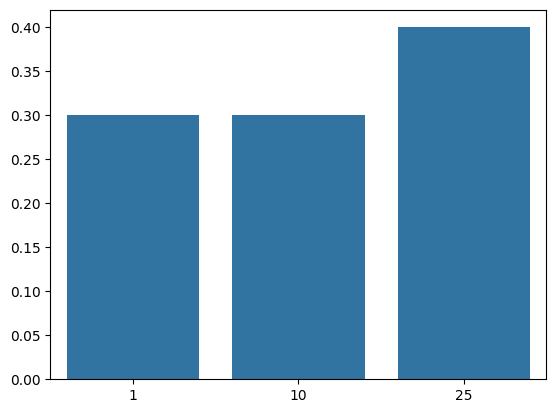

In [236]:
X = [1, 10, 25]                 # Mogelijke uitkomsten. Ongewijzigd laten!!
# Prob_X = [0.1, 0.3, 0.5]      # Vervang door zelf gevonden waarden!!
Prob_X = [0.3, 0.3, 0.4]        # Vervangen door de gevonden waarden!!
sns.barplot(x = X, y = Prob_X)  # Visuele voorstelling. Ongewijzigd laten!!

In [237]:
# 1
Prob_X = [6/20, 6/20, 8/20]

# 2
print(np.sum(np.array(X) * np.array(Prob_X)))


13.3
